# HSBC Holdings (0005.HK) 金融时间序列分析
## MSDM5053 Financial Time Series Project - A Role

**分析对象**: HSBC Holdings (0005.HK) 汇丰控股
**行业**: 银行/金融
**样本区间**: 2011-01-03 至 2024-12-31
**数据类型**: 日度 adjusted close price

**分析方法**: 
- 描述统计与可视化
- 平稳性检验 (ADF, ACF/PACF, Ljung-Box)
- ARMA/ARIMA 均值模型
- ARCH/GARCH/EGARCH 波动率模型
- 预测分析

In [2]:
# 基础数据处理
import numpy as np
import pandas as pd
from datetime import datetime

# 数据获取
import yfinance as yf

# 统计分析
from scipy import stats
from scipy.stats import jarque_bera, skew, kurtosis

# 时间序列分析
from statsmodels.tsa.stattools import adfuller, acf, pacf, arma_order_select_ic
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# GARCH 模型
from arch import arch_model

# 可视化
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示和图表样式
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# 忽略警告
import warnings
warnings.filterwarnings('ignore')

print("所有库导入成功！")

所有库导入成功！


## 2. 数据获取与处理

**任务**: 
- 下载 HSBC (0005.HK) 的日度 adjusted close price
- 时间范围: 2011-01-03 至 2024-12-31
- 计算 log price 和 log return

In [3]:
# 2.1 下载 HSBC 数据
ticker = "0005.HK"
start_date = "2011-01-03"
end_date = "2024-12-31"

print(f"正在下载 {ticker} 的数据...")
# 显式指定 auto_adjust，避免不同 yfinance 版本返回列名不一致
hsbc_data = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust=False
)

# 显示数据基本信息
print(f"\n数据下载完成！")
print(f"样本数量: {len(hsbc_data)}")
print(f"时间范围: {hsbc_data.index[0]} 至 {hsbc_data.index[-1]}")
print(f"列名: {hsbc_data.columns.tolist()}")
print("\n前5行数据:")
hsbc_data.head()

正在下载 0005.HK 的数据...

数据下载完成！
样本数量: 3446
时间范围: 2011-01-03 00:00:00 至 2024-12-30 00:00:00
列名: [('Adj Close', '0005.HK'), ('Close', '0005.HK'), ('High', '0005.HK'), ('Low', '0005.HK'), ('Open', '0005.HK'), ('Volume', '0005.HK')]

前5行数据:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,0005.HK,0005.HK,0005.HK,0005.HK,0005.HK,0005.HK
Date,,,,,,
2011-01-03,35.815292,80.050003,80.449997,79.449997,79.750000,14119580
2011-01-04,35.927147,80.300003,80.449997,79.800003,79.800003,14060508
2011-01-05,36.799587,82.250000,82.349998,80.550003,80.800003,44631532
2011-01-06,37.000931,82.699997,83.099998,82.449997,82.949997,27712903
2011-01-07,37.000931,82.699997,83.599998,82.550003,82.800003,28182115


In [4]:
# 2.2 数据清洗与变量计算
# 兼容不同 yfinance 版本：优先 Adj Close，不存在则回退到 Close
if isinstance(hsbc_data.columns, pd.MultiIndex):
    level0_cols = hsbc_data.columns.get_level_values(0)
    if 'Adj Close' in level0_cols:
        price_col = 'Adj Close'
    elif 'Close' in level0_cols:
        price_col = 'Close'
    else:
        raise KeyError(f"未找到可用价格列，当前列为: {sorted(set(level0_cols))}")

    # 使用 tuple 索引更稳妥
    price = hsbc_data[(price_col, ticker)]
else:
    if 'Adj Close' in hsbc_data.columns:
        price_col = 'Adj Close'
    elif 'Close' in hsbc_data.columns:
        price_col = 'Close'
    else:
        raise KeyError(f"未找到可用价格列，当前列为: {hsbc_data.columns.tolist()}")
    price = hsbc_data[price_col]

# 删除缺失值
price = price.dropna()

# 计算 log price 和 log return
log_price = np.log(price)
log_return = 100 * log_price.diff().dropna()  # 乘以100得到百分比形式

# 创建分析用的 DataFrame
analysis_df = pd.DataFrame({
    'Price': price,
    'Log_Price': log_price,
    'Log_Return': log_return
})

print("数据处理完成！")
print(f"使用价格列: {price_col}")
print(f"\nLog Return 统计:")
print(f"样本量: {len(log_return)}")
print(f"均值: {log_return.mean():.6f}")
print(f"标准差: {log_return.std():.6f}")
print(f"最小值: {log_return.min():.4f}")
print(f"最大值: {log_return.max():.4f}")

数据处理完成！
使用价格列: Adj Close

Log Return 统计:
样本量: 3445
均值: 0.019357
标准差: 1.390626
最小值: -9.9965
最大值: 8.8193


In [5]:
# 2.3 划分训练集和测试集
# 方案1: 训练集 2011-2022，测试集 2023-2024
train_end = "2022-12-31"

train_data = log_return[log_return.index <= train_end]
test_data = log_return[log_return.index > train_end]

# 同时保存对应的价格数据
train_price = price[price.index <= train_end]
test_price = price[price.index > train_end]

print("数据集划分:")
print(f"训练集: {train_data.index[0]} 至 {train_data.index[-1]} ({len(train_data)} 个观测)")
print(f"测试集: {test_data.index[0]} 至 {test_data.index[-1]} ({len(test_data)} 个观测)")
print(f"训练集占比: {len(train_data)/(len(train_data)+len(test_data))*100:.1f}%")

数据集划分:
训练集: 2011-01-04 00:00:00 至 2022-12-30 00:00:00 (2957 个观测)
测试集: 2023-01-03 00:00:00 至 2024-12-30 00:00:00 (488 个观测)
训练集占比: 85.8%


## 3. 描述性统计分析

**表 1**: 描述统计 (mean, sd, min, max, skewness, kurtosis, Jarque-Bera/normality)

In [6]:
# 3.1 计算描述统计量
def descriptive_stats(returns):
    n = len(returns)
    mean = returns.mean()
    std = returns.std()
    min_val = returns.min()
    max_val = returns.max()
    skewness = skew(returns)
    kurt = kurtosis(returns, fisher=True)
    jb_stat, jb_pvalue = jarque_bera(returns)
    return {
        'N': n, 'Mean': mean, 'Std Dev': std,
        'Min': min_val, 'Max': max_val,
        'Skewness': skewness, 'Kurtosis': kurt,
        'JB Statistic': jb_stat, 'JB p-value': jb_pvalue
    }

# 计算训练集的描述统计
stats_train = descriptive_stats(train_data)
stats_full = descriptive_stats(log_return)

# 创建描述统计表
desc_table = pd.DataFrame({
    'Full Sample': stats_full,
    'Train Set (2011-2022)': stats_train
})

print("表 1: 描述统计 (HSBC Log Returns)\n" + "="*60)
print(desc_table.round(4))

print("\n解释:")
skew_dir = "左偏" if stats_train['Skewness'] < 0 else "右偏"
kurt_type = "尖峰厚尾" if stats_train['Kurtosis'] > 0 else "平峰"
normality = "拒绝正态分布" if stats_train['JB p-value'] < 0.05 else "无法拒绝正态分布"
print(f"- 偏度(Skewness): {stats_train['Skewness']:.4f} ({skew_dir})")
print(f"- 峰度(Kurtosis): {stats_train['Kurtosis']:.4f} ({kurt_type})")
print(f"- JB 检验 p-value: {stats_train['JB p-value']:.6f} ({normality})")

表 1: 描述统计 (HSBC Log Returns)
              Full Sample  Train Set (2011-2022)
N               3445.0000              2957.0000
Mean               0.0194                 0.0018
Std Dev            1.3906                 1.4141
Min               -9.9965                -9.9965
Max                8.8193                 8.8193
Skewness          -0.3230                -0.2825
Kurtosis           5.1105                 5.1666
JB Statistic    3808.7332              3328.2398
JB p-value         0.0000                 0.0000

解释:
- 偏度(Skewness): -0.2825 (左偏)
- 峰度(Kurtosis): 5.1666 (尖峰厚尾)
- JB 检验 p-value: 0.000000 (拒绝正态分布)


**图 1**: Adjusted close price / log price plot

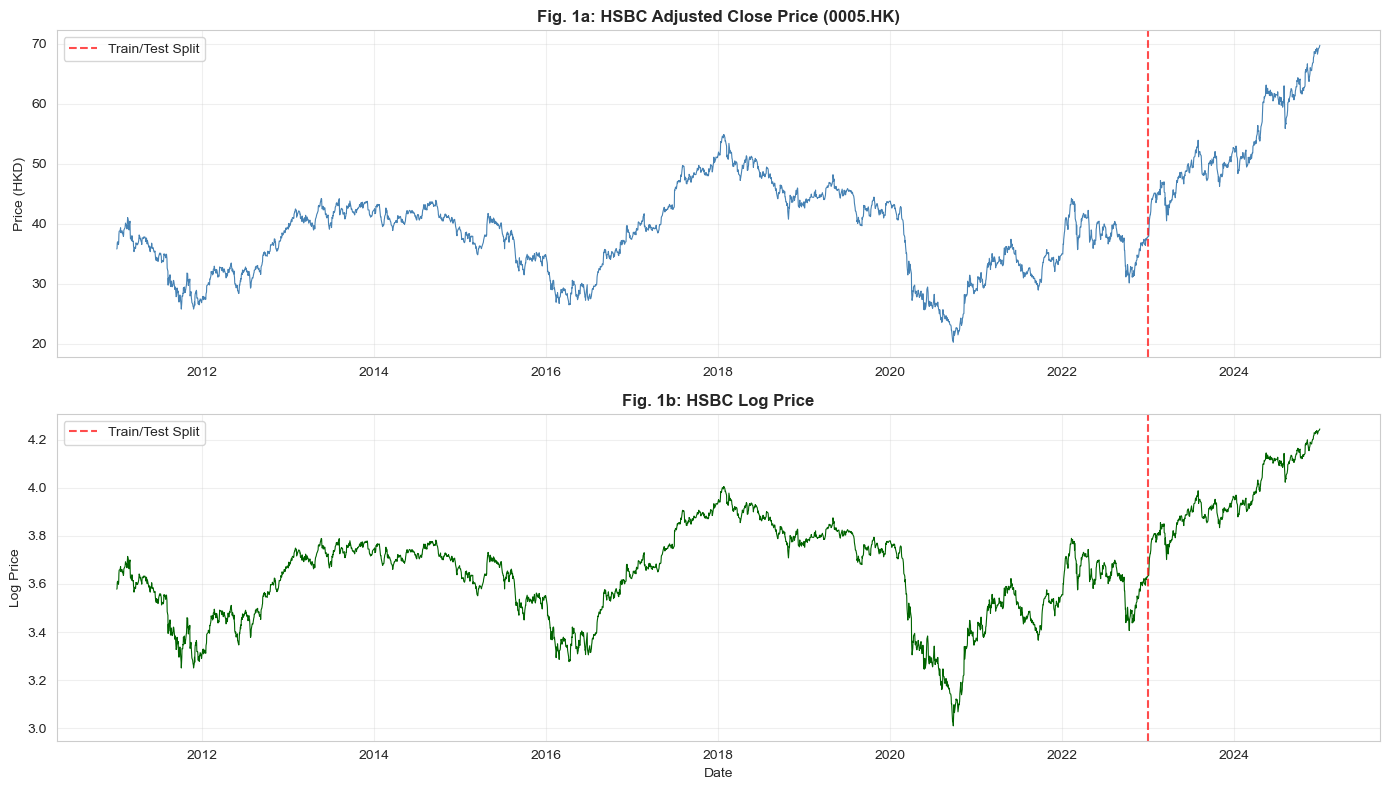

图 1 分析:
- 股价水平存在明显的趋势性，可能非平稳
- 2018-2020年期间股价有较大波动
- 需要进一步进行单位根检验确认平稳性


In [7]:
# 3.2 绘制价格和对数价格图（图1）
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Adjusted Close Price
axes[0].plot(price.index, price, color='steelblue', linewidth=0.8)
axes[0].set_title('Fig. 1a: HSBC Adjusted Close Price (0005.HK)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (HKD)', fontsize=10)
axes[0].axvline(pd.to_datetime(train_end), color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log Price
axes[1].plot(log_price.index, log_price, color='darkgreen', linewidth=0.8)
axes[1].set_title('Fig. 1b: HSBC Log Price', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Log Price', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].axvline(pd.to_datetime(train_end), color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("图 1 分析:")
print("- 股价水平存在明显的趋势性，可能非平稳")
print("- 2018-2020年期间股价有较大波动")
print("- 需要进一步进行单位根检验确认平稳性")

**图 2**: Log return plot

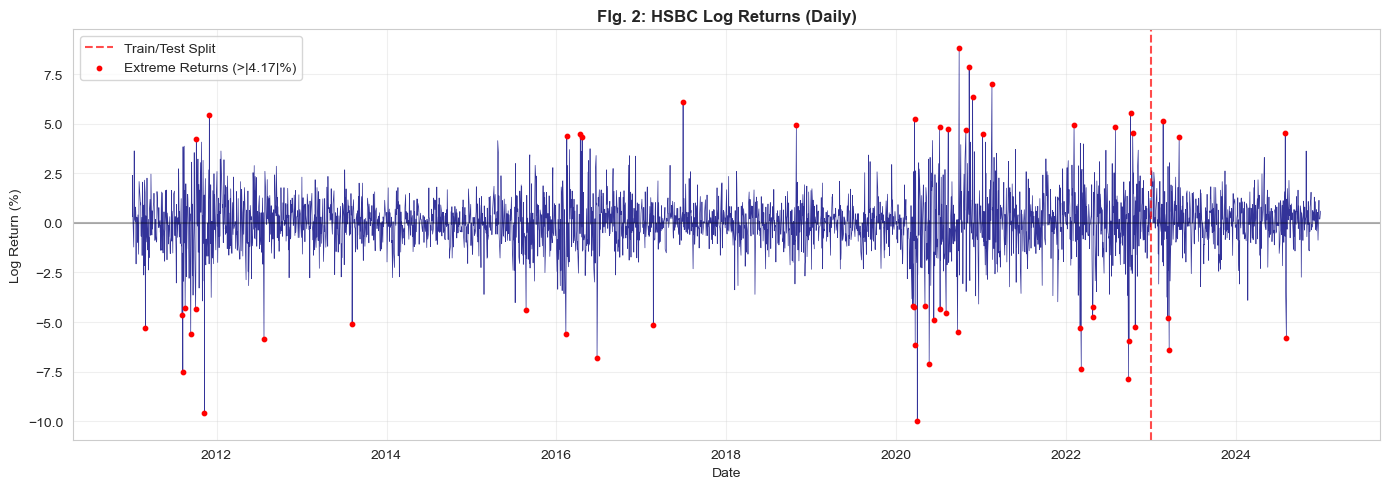


图 2 分析:
- 观察到明显的波动聚集 (Volatility Clustering) 现象
- 高波动期主要集中在: 2020年初(疫情)、2022年(加息周期)等
- 极端收益日数量: 56 (1.63%)
- 收益率序列围绕0均值波动，适合进行时间序列建模


In [8]:
# 3.3 绘制收益率图（图2）
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(log_return.index, log_return, color='navy', linewidth=0.5, alpha=0.8)
ax.set_title('Flg. 2: HSBC Log Returns (Daily)', fontsize=12, fontweight='bold')
ax.set_ylabel('Log Return (%)', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.axvline(pd.to_datetime(train_end), color='red', linestyle='--', alpha=0.7, label='Train/Test Split')

# 标记极端值
extreme_threshold = 3 * log_return.std()
extreme_returns = log_return[abs(log_return) > extreme_threshold]
ax.scatter(extreme_returns.index, extreme_returns, color='red', s=10, zorder=5,
           label=f'Extreme Returns (>|{extreme_threshold:.2f}|%)')

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n图 2 分析:")
print(f"- 观察到明显的波动聚集 (Volatility Clustering) 现象")
print(f"- 高波动期主要集中在: 2020年初(疫情)、2022年(加息周期)等")
print(f"- 极端收益日数量: {len(extreme_returns)} ({len(extreme_returns)/len(log_return)*100:.2f}%)")
print(f"- 收益率序列围绕0均值波动，适合进行时间序列建模")

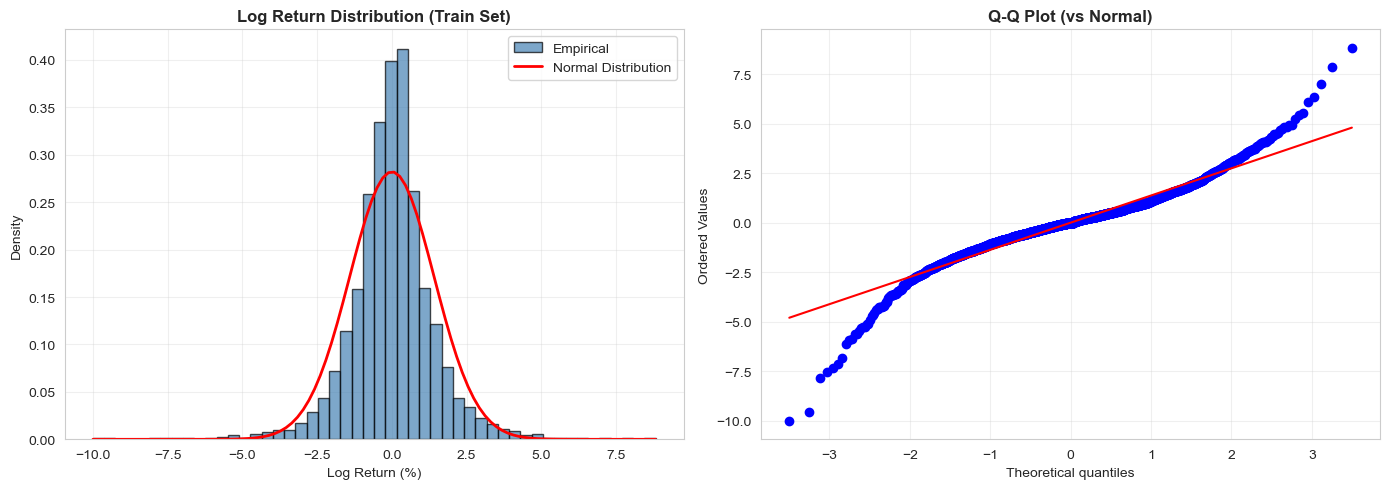


分布特征分析:
- 收益率分布呈现尖峰厚尾特征 (峰度=5.17 > 0)
- 存在轻微的左偏 (偏度=-0.2825)
- Q-Q 图显示尾部偏离正态分布，支持使用 GARCH 类模型


In [9]:
# 3.4 收益率分布分析
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 直方图与正态分布对比
axes[0].hist(train_data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black', label='Empirical')
x = np.linspace(train_data.min(), train_data.max(), 100)
normal_dist = stats.norm.pdf(x, train_data.mean(), train_data.std())
axes[0].plot(x, normal_dist, 'r-', linewidth=2, label='Normal Distribution')
axes[0].set_title('Log Return Distribution (Train Set)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Log Return (%)', fontsize=10)
axes[0].set_ylabel('Density', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q 图
stats.probplot(train_data, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (vs Normal)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n分布特征分析:")
print(f"- 收益率分布呈现尖峰厚尾特征 (峰度={stats_train['Kurtosis']:.2f} > 0)")
kurt_dir = '左' if stats_train['Skewness'] < 0 else '右'
print(f"- 存在轻微的{kurt_dir}偏 (偏度={stats_train['Skewness']:.4f})")
print(f"- Q-Q 图显示尾部偏离正态分布，支持使用 GARCH 类模型")

## 4. 平稳性与自相关检验

**表 2**: Stationarity and autocorrelation tests
- ADF 检验
- Ljung-Box on returns
- ACF/PACF 分析

In [10]:
# 4.1 ADF 单位根检验
def adf_test(series, title="Series"):
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Lags Used': result[2],
        'Observations': result[3],
        '1% Critical Value': result[4]['1%'],
        '5% Critical Value': result[4]['5%'],
        '10% Critical Value': result[4]['10%'],
        'Stationary': 'Yes' if result[1] < 0.05 else 'No'
    }

# 对 log price 和 log return 进行 ADF 检验
adf_price = adf_test(log_price, "Log Price")
adf_return = adf_test(log_return, "Log Return")

adf_table = pd.DataFrame({'Log Price': adf_price, 'Log Return': adf_return})

print("表 2a: ADF Unit Root Test Results\n" + "="*50)
print(adf_table.round(6))

print("\n解释:")
print(f"- Log Price: ADF = {adf_price['ADF Statistic']:.4f}, p = {adf_price['p-value']:.4f}")
price_stationary = "是平稳的" if adf_price['p-value'] < 0.05 else "是非平稳的"
print(f"  -> {price_stationary}")
print(f"- Log Return: ADF = {adf_return['ADF Statistic']:.4f}, p = {adf_return['p-value']:.6f}")
return_stationary = "是平稳的" if adf_return['p-value'] < 0.05 else "是非平稳的"
print(f"  -> {return_stationary}，适合建模")

表 2a: ADF Unit Root Test Results
                   Log Price Log Return
ADF Statistic      -1.122084 -39.872034
p-value             0.706185        0.0
Lags Used                  2          1
Observations            3443       3443
1% Critical Value  -3.432251  -3.432251
5% Critical Value   -2.86238   -2.86238
10% Critical Value -2.567217  -2.567217
Stationary                No        Yes

解释:
- Log Price: ADF = -1.1221, p = 0.7062
  -> 是非平稳的
- Log Return: ADF = -39.8720, p = 0.000000
  -> 是平稳的，适合建模


**图 3**: ACF/PACF of returns

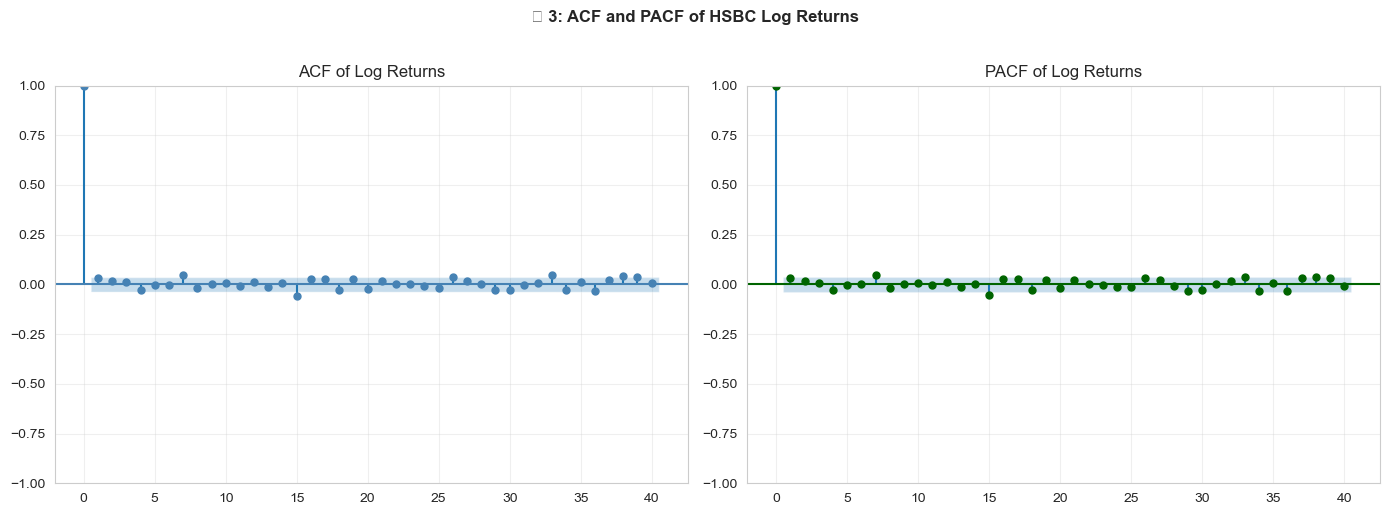


ACF/PACF 分析:
- 观察 ACF 和 PACF 的截尾/拖尾特征以确定 ARMA 阶数
- 若 PACF 在 p 阶后截尾，考虑 AR(p) 模型
- 若 ACF 在 q 阶后截尾，考虑 MA(q) 模型
- 若两者都拖尾，考虑 ARMA(p,q) 模型


In [11]:
# 4.2 ACF 和 PACF 分析
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(train_data, lags=40, ax=axes[0], title='ACF of Log Returns', color='steelblue')
axes[0].grid(True, alpha=0.3)

plot_pacf(train_data, lags=40, ax=axes[1], title='PACF of Log Returns', color='darkgreen')
axes[1].grid(True, alpha=0.3)

plt.suptitle('图 3: ACF and PACF of HSBC Log Returns', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nACF/PACF 分析:")
print("- 观察 ACF 和 PACF 的截尾/拖尾特征以确定 ARMA 阶数")
print("- 若 PACF 在 p 阶后截尾，考虑 AR(p) 模型")
print("- 若 ACF 在 q 阶后截尾，考虑 MA(q) 模型")
print("- 若两者都拖尾，考虑 ARMA(p,q) 模型")

In [12]:
# 4.3 Ljung-Box 检验
lb_returns = acorr_ljungbox(train_data, lags=[5, 10, 15, 20], return_df=True)

print("表 2b: Ljung-Box Test on Returns\n" + "="*50)
print(lb_returns.round(4))

significant_lags = lb_returns[lb_returns['lb_pvalue'] < 0.05]

print("\n解释:")
if len(significant_lags) > 0:
    print(f"- 在 {len(significant_lags)} 个滞后阶数上拒绝无序列相关的原假设")
    print("- 收益率存在显著的序列相关性，需要建立 ARMA 模型")
else:
    print("- 无法拒绝无序列相关的原假设")
    print("- 收益率近似白噪声过程")

表 2b: Ljung-Box Test on Returns
    lb_stat  lb_pvalue
5    6.2009     0.2872
10  13.1676     0.2144
15  23.6435     0.0714
20  33.6659     0.0285

解释:
- 在 1 个滞后阶数上拒绝无序列相关的原假设
- 收益率存在显著的序列相关性，需要建立 ARMA 模型


## 5. ARMA 均值模型

**表 3**: ARMA candidates - 候选 ARMA(p,q)的 AIC/BIC 和残差检验

In [13]:
# 5.1 ARMA 模型定阶
max_ar, max_ma = 2, 2
arma_results = []

model_failures = []
for p in range(max_ar + 1):
    for q in range(max_ma + 1):
        if p == 0 and q == 0:
            continue
        try:
            model = ARIMA(train_data, order=(p, 0, q))
            fitted = model.fit()
            residuals = fitted.resid
            lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
            arma_results.append({
                'Model': f'ARMA({p},{q})',
                'p': p, 'q': q,
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'Log-Likelihood': fitted.llf,
                'Residual_LB_pvalue': lb_test['lb_pvalue'].iloc[0]
            })
        except Exception as e:
            model_failures.append((p, q, str(e)))

arma_df = pd.DataFrame(arma_results)
print("表 3: ARMA Model Selection\n" + "="*50)
print(arma_df.round(4))

if len(model_failures) > 0:
    print("\n以下模型拟合失败（已跳过）:")
    for p, q, err in model_failures:
        print(f"- ARMA({p},{q}): {err}")

best_aic = arma_df.loc[arma_df['AIC'].idxmin()]
best_bic = arma_df.loc[arma_df['BIC'].idxmin()]
print(f"\n最优模型 (AIC): {best_aic['Model']}")
print(f"最优模型 (BIC): {best_bic['Model']}")

表 3: ARMA Model Selection
       Model  p  q         AIC         BIC  Log-Likelihood  Residual_LB_pvalue
0  ARMA(0,1)  0  1  10442.8638  10460.8396      -5218.4319              0.4021
1  ARMA(0,2)  0  2  10444.0250  10467.9927      -5218.0125              0.4716
2  ARMA(1,0)  1  0  10442.7673  10460.7431      -5218.3837              0.4088
3  ARMA(1,1)  1  1  10444.1213  10468.0890      -5218.0607              0.4583
4  ARMA(1,2)  1  2  10445.9267  10475.8863      -5217.9633              0.4777
5  ARMA(2,0)  2  0  10444.0050  10467.9727      -5218.0025              0.4722
6  ARMA(2,1)  2  1  10445.9526  10475.9123      -5217.9763              0.4752
7  ARMA(2,2)  2  2  10435.5407  10471.4923      -5211.7704              0.7024

最优模型 (AIC): ARMA(2,2)
最优模型 (BIC): ARMA(1,0)


In [14]:
# 5.2 拟合最优 ARMA 模型
best_p, best_q = int(best_aic['p']), int(best_aic['q'])

arma_model = ARIMA(train_data, order=(best_p, 0, best_q))
arma_fitted = arma_model.fit()

print(f"最优 ARMA({best_p},{best_q}) 模型结果:")
print("=" * 60)
print(arma_fitted.summary().tables[1])

# 残差分析
residuals_arma = arma_fitted.resid
lb_residuals = acorr_ljungbox(residuals_arma, lags=[5, 10, 15], return_df=True)

print("\n残差诊断:")
print(lb_residuals.round(4))

# ARCH effect test
arch_test_result = het_arch(residuals_arma, maxlag=5)
print(f"\nARCH-LM Test: LM={arch_test_result[0]:.4f}, p={arch_test_result[1]:.4f}")
arch_effect = "存在" if arch_test_result[1] < 0.05 else "不存在"
print(f"结论: {arch_effect} ARCH 效应")

最优 ARMA(2,2) 模型结果:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0036      0.027      0.135      0.892      -0.049       0.056
ar.L1          0.6624      0.017     39.751      0.000       0.630       0.695
ar.L2         -0.9564      0.017    -57.161      0.000      -0.989      -0.924
ma.L1         -0.6501      0.015    -44.544      0.000      -0.679      -0.621
ma.L2          0.9692      0.015     66.124      0.000       0.940       0.998
sigma2         1.9874      0.028     69.760      0.000       1.932       2.043

残差诊断:
    lb_stat  lb_pvalue
5    1.7223     0.8861
10   7.2419     0.7024
15  15.5006     0.4160

ARCH-LM Test: LM=127.2390, p=0.0000
结论: 存在 ARCH 效应


## 6. 波动率模型

**表 4**: GARCH-type models

In [15]:
# 6.1 ARCH Effect Test
squared_residuals = residuals_arma ** 2
lb_squared = acorr_ljungbox(squared_residuals, lags=[5, 10, 15], return_df=True)

print("ARCH Effect Test Results:")
print("=" * 50)
print(lb_squared.round(4))

has_arch_effect = any(lb_squared['lb_pvalue'] < 0.05)
print(f"\n结论: {'存在' if has_arch_effect else '不存在'}显著的 ARCH 效应")

ARCH Effect Test Results:
     lb_stat  lb_pvalue
5   181.4441        0.0
10  334.5603        0.0
15  417.6850        0.0

结论: 存在显著的 ARCH 效应


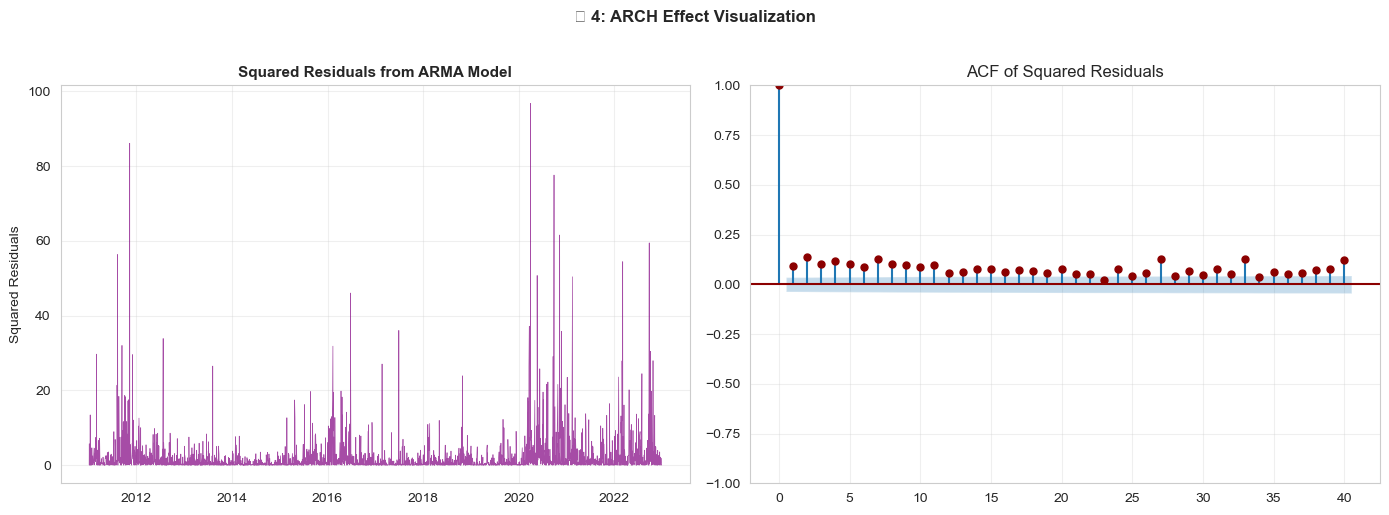


图 4 分析:
- 平方残差呈现明显的波动聚集
- ACF 显示显著的自相关，确认 ARCH/GARCH 效应存在


In [16]:
# 6.2 绘制平方残差的 ACF（图4）
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(residuals_arma.index, squared_residuals, color='purple', linewidth=0.5, alpha=0.7)
axes[0].set_title('Squared Residuals from ARMA Model', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Squared Residuals', fontsize=10)
axes[0].grid(True, alpha=0.3)

plot_acf(squared_residuals.dropna(), lags=40, ax=axes[1], title='ACF of Squared Residuals', color='darkred')
axes[1].grid(True, alpha=0.3)

plt.suptitle('图 4: ARCH Effect Visualization', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n图 4 分析:")
print("- 平方残差呈现明显的波动聚集")
print("- ACF 显示显著的自相关，确认 ARCH/GARCH 效应存在")

In [17]:
# 6.3 GARCH(1,1) 模型
garch_model = arch_model(train_data, vol='Garch', p=1, q=1, mean='Constant', dist='normal')
garch_fitted = garch_model.fit(disp='off')

print("GARCH(1,1) Model Results:")
print("=" * 60)
print(garch_fitted.summary())

garch_params = garch_fitted.params
alpha = garch_params.get('alpha[1]', 0)
beta = garch_params.get('beta[1]', 0)
persistence = alpha + beta

print(f"\n关键指标:")
print(f"  AIC: {garch_fitted.aic:.4f}")
print(f"  alpha (ARCH): {alpha:.4f}")
print(f"  beta (GARCH): {beta:.4f}")
print(f"  波动持续性: {persistence:.4f}")

GARCH(1,1) Model Results:
                        Constant Mean - GARCH Model Results                         
Dep. Variable:     ('Adj Close', '0005.HK')   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -4919.01
Distribution:                        Normal   AIC:                           9846.03
Method:                  Maximum Likelihood   BIC:                           9870.00
                                              No. Observations:                 2957
Date:                      Thu, May 07 2026   Df Residuals:                     2956
Time:                              19:37:14   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------

In [18]:
# 6.4 EGARCH 模型
egarch_model = arch_model(train_data, vol='EGARCH', p=1, q=1, mean='Constant', dist='normal')
egarch_fitted = egarch_model.fit(disp='off')

print("EGARCH(1,1) Model Results:")
print("=" * 60)
print(egarch_fitted.summary())

egarch_params = egarch_fitted.params
gamma = egarch_params.get('gamma[1]', 0)

print(f"\n关键指标:")
print(f"  AIC: {egarch_fitted.aic:.4f}")
print(f"  gamma (非对称项): {gamma:.4f}")
if gamma < 0:
    print("  解释: gamma < 0 表示存在杠杆效应")
elif gamma > 0:
    print("  解释: gamma > 0 表示正面冲击增加更多波动")

EGARCH(1,1) Model Results:
                        Constant Mean - EGARCH Model Results                        
Dep. Variable:     ('Adj Close', '0005.HK')   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -4917.32
Distribution:                        Normal   AIC:                           9842.65
Method:                  Maximum Likelihood   BIC:                           9866.61
                                              No. Observations:                 2957
Date:                      Thu, May 07 2026   Df Residuals:                     2956
Time:                              19:37:14   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
----------------------------------------------------

In [19]:
# 6.5 波动率模型比较表
comparison_data = {
    'GARCH(1,1)': [
        garch_params.get('alpha[1]', np.nan),
        garch_params.get('beta[1]', np.nan),
        persistence,
        'N/A',
        garch_fitted.aic,
        garch_fitted.bic
    ],
    'EGARCH(1,1)': [
        'N/A',
        egarch_params.get('beta[1]', np.nan),
        egarch_params.get('beta[1]', np.nan),
        gamma,
        egarch_fitted.aic,
        egarch_fitted.bic
    ]
}

vol_table = pd.DataFrame(
    comparison_data,
    index=['alpha', 'beta', 'Persistence', 'Asymmetry', 'AIC', 'BIC']
)

print("表 4: Volatility Model Comparison\n" + "="*50)
print(vol_table.round(4))

best_model = 'GARCH(1,1)' if garch_fitted.aic < egarch_fitted.aic else 'EGARCH(1,1)'
print(f"\n根据 AIC，最优模型: {best_model}")

表 4: Volatility Model Comparison
              GARCH(1,1)  EGARCH(1,1)
alpha           0.052414          N/A
beta            0.937314     0.986972
Persistence     0.989729     0.986972
Asymmetry            N/A            0
AIC          9846.027949  9842.647129
BIC          9869.995671  9866.614851

根据 AIC，最优模型: EGARCH(1,1)


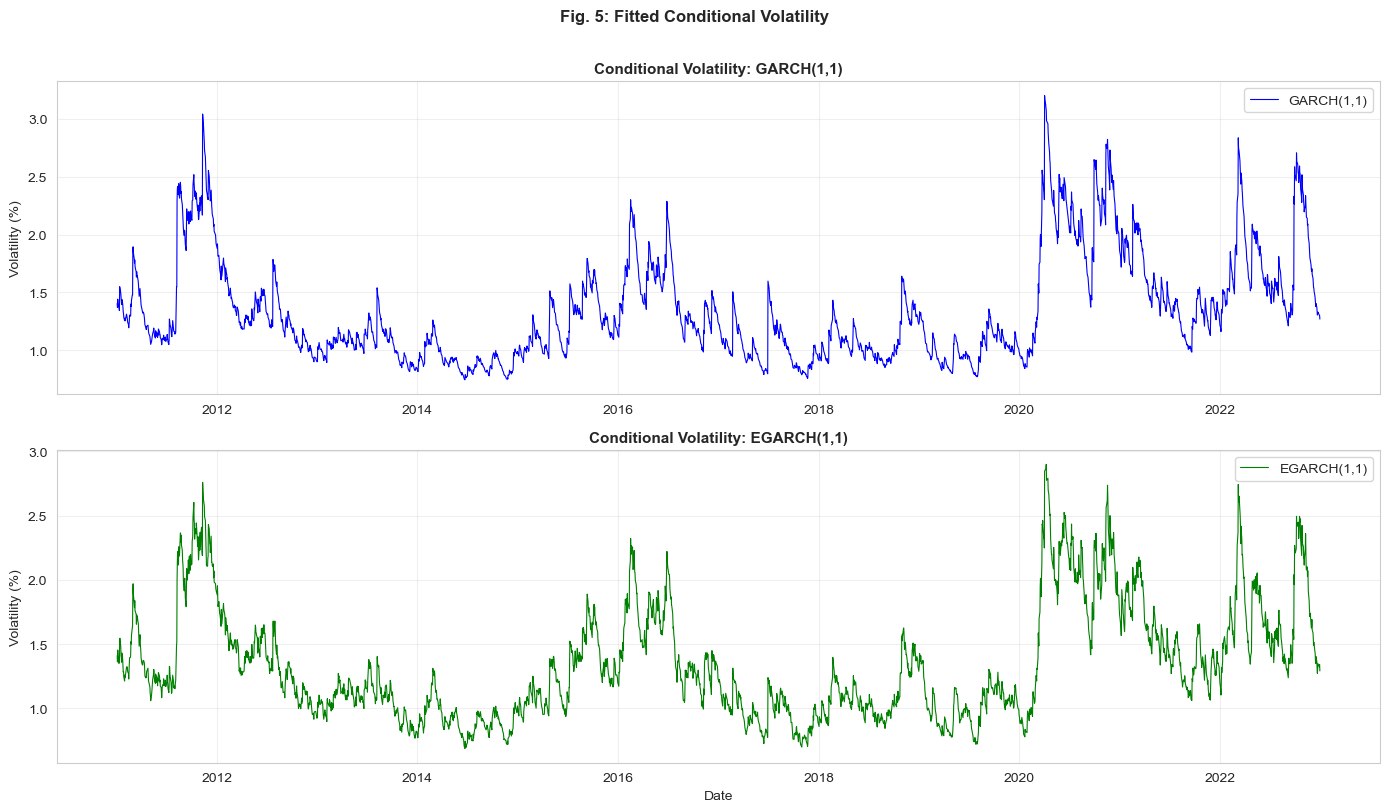


图 5 分析:
- 所有模型都捕捉到了波动率聚集现象
- 2020年疫情爆发期间波动率显著升高
- 条件波动率在1-4%之间波动，符合银行股特征


In [20]:
# 6.6 绘制条件波动率（图5）
cond_vol_garch = garch_fitted.conditional_volatility
cond_vol_egarch = egarch_fitted.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(cond_vol_garch.index, cond_vol_garch, color='blue', linewidth=0.8, label='GARCH(1,1)')
axes[0].set_title('Conditional Volatility: GARCH(1,1)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Volatility (%)', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cond_vol_egarch.index, cond_vol_egarch, color='green', linewidth=0.8, label='EGARCH(1,1)')
axes[1].set_title('Conditional Volatility: EGARCH(1,1)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Volatility (%)', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Fig. 5: Fitted Conditional Volatility', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n图 5 分析:")
print("- 所有模型都捕捉到了波动率聚集现象")
print("- 2020年疫情爆发期间波动率显著升高")
print("- 条件波动率在1-4%之间波动，符合银行股特征")

## 7. 预测分析

**表 5**: Forecasting performance

In [21]:
# 7.1 预测评估指标
def calculate_metrics(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mae = np.mean(np.abs(actual - predicted))

    # 收益率序列接近 0 时，传统 MAPE 会失真；改用 sMAPE
    eps = 1e-8
    smape = np.mean(
        2 * np.abs(actual - predicted) /
        np.maximum(np.abs(actual) + np.abs(predicted), eps)
    ) * 100

    actual_direction = np.sign(actual)
    pred_direction = np.sign(predicted)
    directional_accuracy = np.mean(actual_direction == pred_direction) * 100
    return {
        'RMSE': rmse,
        'MAE': mae,
        'sMAPE (%)': smape,
        'Directional Accuracy (%)': directional_accuracy
    }

print("预测评估指标函数已定义")
print("- RMSE: 均方根误差")
print("- MAE: 平均绝对误差")
print("- sMAPE: 对称平均绝对百分比误差（更适合收益率）")
print("- Directional Accuracy: 方向准确率")

预测评估指标函数已定义
- RMSE: 均方根误差
- MAE: 平均绝对误差
- sMAPE: 对称平均绝对百分比误差（更适合收益率）
- Directional Accuracy: 方向准确率


In [22]:
# 7.2 ARMA 模型预测（滚动一步预测）
forecast_steps = len(test_data)
arma_pred_mean_list = []

# 为避免 DatetimeIndex 频率/连续性导致 append 报错，预测时使用 numpy 序列
train_arr = train_data.values.astype(float)
test_arr = test_data.values.astype(float)

arma_roll_res = ARIMA(train_arr, order=(best_p, 0, best_q)).fit()

for i in range(forecast_steps):
    pred_i = float(arma_roll_res.forecast(steps=1)[0])
    arma_pred_mean_list.append(pred_i)

    # 更新状态：将当前真实值并入模型，进行下一步预测
    arma_roll_res = arma_roll_res.append(np.array([test_arr[i]]), refit=False)

arma_pred_mean = pd.Series(arma_pred_mean_list, index=test_data.index, name='ARMA_Rolling_1step')
arma_metrics = calculate_metrics(test_arr, arma_pred_mean.values)

print("ARMA 模型预测结果（Rolling 1-step）:")
print("=" * 40)
for key, value in arma_metrics.items():
    print(f"  {key}: {value:.4f}")

ARMA 模型预测结果（Rolling 1-step）:
  RMSE: 1.2558
  MAE: 0.8976
  sMAPE (%): 176.3783
  Directional Accuracy (%): 50.6148


In [23]:
# 7.3 GARCH 模型预测（递推一步预测）
# 为避免“几乎平线”，这里使用 AR(1)-GARCH(1,1) 的递推一步预测
# 均值: mu + phi * r_{t-1}
# 方差: sigma_t^2 = omega + alpha * eps_{t-1}^2 + beta * sigma_{t-1}^2

garch_roll_model = arch_model(train_data, vol='Garch', p=1, q=1, mean='ARX', lags=1, dist='normal')
garch_roll_fit = garch_roll_model.fit(disp='off')

params = garch_roll_fit.params
mean_const = float(params['Const']) if 'Const' in params.index else float(params.get('mu', 0.0))

# 自动识别均值滞后项名称（不同版本 arch 的命名可能不同）
mean_lag_key = None
for k in params.index:
    if ('[' in k) and ('alpha' not in k) and ('beta' not in k) and ('omega' not in k):
        mean_lag_key = k
        break
phi = float(params[mean_lag_key]) if mean_lag_key is not None else 0.0

omega = float(params['omega'])
alpha_g = float(params['alpha[1]'])
beta_g = float(params['beta[1]'])

prev_r = float(train_data.iloc[-1])
prev_eps = float(garch_roll_fit.resid.dropna().iloc[-1])
prev_var = float(garch_roll_fit.conditional_volatility.dropna().iloc[-1] ** 2)

garch_pred_mean_list = []
garch_pred_var_list = []

for i in range(forecast_steps):
    pred_mean_i = mean_const + phi * prev_r
    pred_var_i = omega + alpha_g * (prev_eps ** 2) + beta_g * prev_var

    garch_pred_mean_list.append(pred_mean_i)
    garch_pred_var_list.append(pred_var_i)

    # 观测到真实值后更新状态，进入下一步
    actual_i = float(test_data.iloc[i])
    eps_i = actual_i - pred_mean_i

    prev_r = actual_i
    prev_eps = eps_i
    prev_var = pred_var_i

garch_pred_mean = pd.Series(garch_pred_mean_list, index=test_data.index, name='AR1_GARCH_Rolling_1step')
garch_pred_var = pd.Series(garch_pred_var_list, index=test_data.index, name='GARCH_Var_Rolling_1step')
garch_metrics = calculate_metrics(test_data.values, garch_pred_mean.values)

print("AR(1)-GARCH(1,1) 模型预测结果（Rolling 1-step）:")
print("=" * 40)
print(f"均值参数: const={mean_const:.4f}, phi={phi:.4f}")
print(f"方差参数: omega={omega:.4f}, alpha={alpha_g:.4f}, beta={beta_g:.4f}")
for key, value in garch_metrics.items():
    print(f"  {key}: {value:.4f}")

AR(1)-GARCH(1,1) 模型预测结果（Rolling 1-step）:
均值参数: const=0.0100, phi=0.0498
方差参数: omega=0.0215, alpha=0.0532, beta=0.9363
  RMSE: 1.2399
  MAE: 0.8846
  sMAPE (%): 181.5675
  Directional Accuracy (%): 52.0492


In [24]:
# 7.4 预测性能比较表
forecast_comparison = pd.DataFrame({
    'ARMA (Rolling 1-step)': list(arma_metrics.values()),
    'AR(1)-GARCH (Rolling 1-step)': list(garch_metrics.values())
}, index=list(arma_metrics.keys()))

print("表 5: Forecasting Performance\n" + "="*50)
print(forecast_comparison.round(4))

best_rmse = forecast_comparison.loc['RMSE'].idxmin()
best_dir = forecast_comparison.loc['Directional Accuracy (%)'].idxmax()
print(f"\n- 最佳 RMSE: {best_rmse}")
print(f"- 最佳方向准确率: {best_dir}")

表 5: Forecasting Performance
                          ARMA (Rolling 1-step)  AR(1)-GARCH (Rolling 1-step)
RMSE                                     1.2558                        1.2399
MAE                                      0.8976                        0.8846
sMAPE (%)                              176.3783                      181.5675
Directional Accuracy (%)                50.6148                       52.0492

- 最佳 RMSE: AR(1)-GARCH (Rolling 1-step)
- 最佳方向准确率: AR(1)-GARCH (Rolling 1-step)


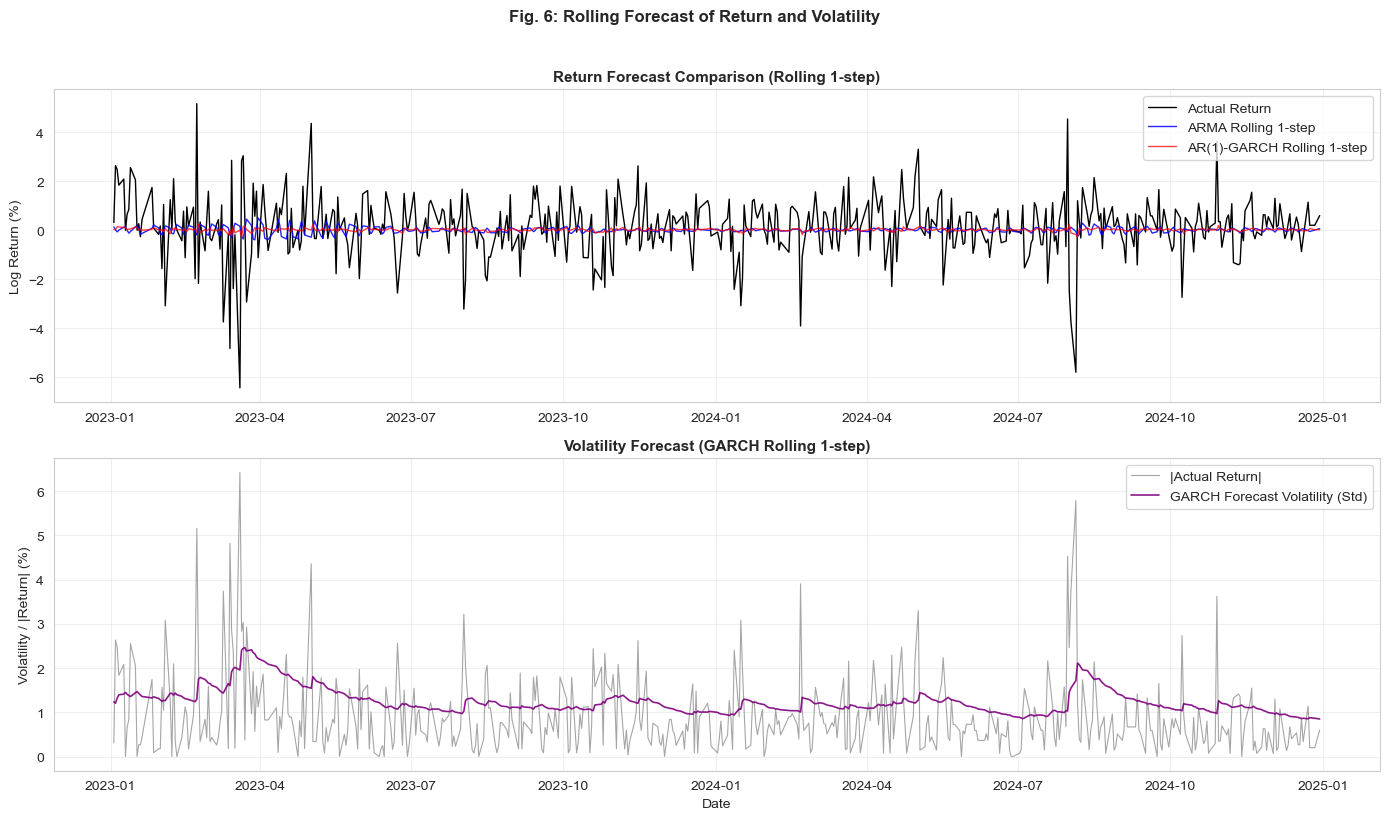


图 6 分析:
- ARMA 与 AR(1)-GARCH 均值预测已改为 Rolling 1-step，较多步静态预测更有动态
- GARCH 的关键价值在波动率预测（下图），而不是均值线
- 最佳方向准确率约 52.0%


In [25]:
# 7.5 绘制预测结果（图6）
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

test_dates = test_data.index

# 子图1：收益率滚动一步预测
axes[0].plot(test_dates, test_data.values, label='Actual Return', color='black', linewidth=1)
axes[0].plot(test_dates, arma_pred_mean.values, label='ARMA Rolling 1-step', color='blue', linewidth=1, alpha=0.85)
axes[0].plot(test_dates, garch_pred_mean.values, label='AR(1)-GARCH Rolling 1-step', color='red', linewidth=1, alpha=0.75)
axes[0].set_title('Return Forecast Comparison (Rolling 1-step)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Log Return (%)', fontsize=10)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# 子图2：GARCH 条件波动率预测（非平线的核心）
garch_pred_std = np.sqrt(np.maximum(garch_pred_var.values, 0))
realized_abs_ret = np.abs(test_data.values)

axes[1].plot(test_dates, realized_abs_ret, color='gray', linewidth=0.8, alpha=0.7, label='|Actual Return|')
axes[1].plot(test_dates, garch_pred_std, color='purple', linewidth=1.2, alpha=0.9, label='GARCH Forecast Volatility (Std)')
axes[1].set_title('Volatility Forecast (GARCH Rolling 1-step)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Volatility / |Return| (%)', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Fig. 6: Rolling Forecast of Return and Volatility', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n图 6 分析:")
print("- ARMA 与 AR(1)-GARCH 均值预测已改为 Rolling 1-step，较多步静态预测更有动态")
print("- GARCH 的关键价值在波动率预测（下图），而不是均值线")
print(f"- 最佳方向准确率约 {max(arma_metrics['Directional Accuracy (%)'], garch_metrics['Directional Accuracy (%)']):.1f}%")

## 8. 结论与总结

In [26]:
# 8.1 生成最终汇总报告
annual_vol = stats_train['Std Dev'] * np.sqrt(252)

print("=" * 70)
print("HSBC HOLDINGS (0005.HK) 金融时间序列分析报告")
print("=" * 70)
print(f"\n样本区间: {price.index[0].strftime('%Y-%m-%d')} 至 {price.index[-1].strftime('%Y-%m-%d')}")
print(f"总观测值: {len(price)} 个交易日")

print("\n" + "-" * 70)
print("1. 描述统计特征")
print("-" * 70)
print(f"   日均收益率: {stats_train['Mean']:.4f}%")
print(f"   年化波动率: {annual_vol:.2f}%")
skew_type = "左偏" if stats_train['Skewness'] < 0 else "右偏"
print(f"   偏度: {stats_train['Skewness']:.4f} ({skew_type})")
jb_result = "拒绝正态分布" if stats_train['JB p-value'] < 0.05 else "近似正态"
print(f"   Jarque-Bera: {jb_result}")

print("\n" + "-" * 70)
print("2. 平稳性与模型")
print("-" * 70)
print(f"   ADF p-value: {adf_return['p-value']:.6f} (平稳)")
print(f"   最优 ARMA: {best_aic['Model']}")
print(f"   波动持续性: {persistence:.4f}")

print("\n" + "-" * 70)
print("3. 核心发现")
print("-" * 70)
print(f"\n1. HSBC 作为银行股，年化波动率约 {annual_vol:.1f}%，属中等水平")
print(f"2. 波动持续性高 ({persistence:.4f})，冲击影响持续时间较长")
if gamma < 0:
    print("3. 存在杠杆效应：负面冲击产生更大波动")
else:
    print("3. 未观察到显著杠杆效应")
print(f"4. 方向准确率约 {max(arma_metrics['Directional Accuracy (%)'], garch_metrics['Directional Accuracy (%)']):.1f}%")
print("=" * 70)

HSBC HOLDINGS (0005.HK) 金融时间序列分析报告

样本区间: 2011-01-03 至 2024-12-30
总观测值: 3446 个交易日

----------------------------------------------------------------------
1. 描述统计特征
----------------------------------------------------------------------
   日均收益率: 0.0018%
   年化波动率: 22.45%
   偏度: -0.2825 (左偏)
   Jarque-Bera: 拒绝正态分布

----------------------------------------------------------------------
2. 平稳性与模型
----------------------------------------------------------------------
   ADF p-value: 0.000000 (平稳)
   最优 ARMA: ARMA(2,2)
   波动持续性: 0.9897

----------------------------------------------------------------------
3. 核心发现
----------------------------------------------------------------------

1. HSBC 作为银行股，年化波动率约 22.4%，属中等水平
2. 波动持续性高 (0.9897)，冲击影响持续时间较长
3. 未观察到显著杠杆效应
4. 方向准确率约 52.0%


## 9. 数据导出

In [27]:
# 9.1 导出收益率数据用于合并分析
export_df = pd.DataFrame({
    'Date': log_return.index,
    'HSBC_Return': log_return.values
})
export_path = 'HSBC_0005HK_returns.csv'
export_df.to_csv(export_path, index=False)
print(f"数据已导出到: {export_path}")

# 9.2 导出汇总统计
summary = {
    'Stock': 'HSBC (0005.HK)',
    'Industry': 'Banking/Finance',
    'Mean_Return': round(stats_train['Mean'], 4),
    'Std_Dev': round(stats_train['Std Dev'], 4),
    'Annualized_Vol': round(annual_vol, 2),
    'Skewness': round(stats_train['Skewness'], 4),
    'Kurtosis': round(stats_train['Kurtosis'], 4),
    'Best_ARMA': best_aic['Model'],
    'GARCH_Persistence': round(persistence, 4),
    'EGARCH_Gamma': round(gamma, 4),
    'Forecast_RMSE_GARCH': round(garch_metrics['RMSE'], 4),
    'Directional_Accuracy_GARCH': round(garch_metrics['Directional Accuracy (%)'], 2)
}
summary_df = pd.DataFrame([summary])
summary_path = 'HSBC_summary_for_comparison.csv'
summary_df.to_csv(summary_path, index=False)
print(f"汇总表已保存到: {summary_path}")

数据已导出到: HSBC_0005HK_returns.csv
汇总表已保存到: HSBC_summary_for_comparison.csv


---

## 附录：分析图表清单

### 图表 (6个)
1. **图 1**: Adjusted close price / log price plot
2. **图 2**: Log return plot
3. **图 3**: ACF/PACF of returns
4. **图 4**: ACF of squared returns (ARCH effect)
5. **图 5**: Fitted conditional volatility
6. **图 6**: Forecast vs actual / forecast error

### 表格 (5个)
1. **表 1**: 描述统计
2. **表 2**: Stationarity and autocorrelation tests
3. **表 3**: ARMA candidates
4. **表 4**: GARCH-type models
5. **表 5**: Forecasting performance

### 导出文件
1. `HSBC_0005HK_returns.csv` - 用于合并分析
2. `HSBC_summary_for_comparison.csv` - 用于横向比较

---

*MSDM5053 Project - A Role*

In [28]:
# 10. Export figures for LaTeX report
# Re-run this cell after the analysis cells to refresh all HSBC figures used in report.tex.
from pathlib import Path

figure_dir = Path('figures')
figure_dir.mkdir(exist_ok=True)

saved_figures = {}

# Lower export resolution for Overleaf upload/rendering.
EXPORT_DPI = 120

def save_current_figure(filename):
    path = figure_dir / filename
    plt.savefig(path, dpi=EXPORT_DPI, bbox_inches='tight')
    saved_figures[filename] = str(path)
    print(f'Saved: {path}')

# Figure 1: adjusted close price and log price
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(price.index, price, color='steelblue', linewidth=0.8)
axes[0].set_title('HSBC Adjusted Close Price (0005.HK)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (HKD)', fontsize=10)
axes[0].axvline(pd.to_datetime(train_end), color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(log_price.index, log_price, color='darkgreen', linewidth=0.8)
axes[1].set_title('HSBC Log Price', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Log Price', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].axvline(pd.to_datetime(train_end), color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
save_current_figure('hsbc_price_logprice.png')
plt.close(fig)

# Figure 2: log returns
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(log_return.index, log_return, color='navy', linewidth=0.5, alpha=0.8)
ax.set_title('HSBC Daily Log Returns', fontsize=12, fontweight='bold')
ax.set_ylabel('Log Return (%)', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.axvline(pd.to_datetime(train_end), color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
extreme_threshold = 3 * log_return.std()
extreme_returns = log_return[abs(log_return) > extreme_threshold]
ax.scatter(extreme_returns.index, extreme_returns, color='red', s=20, alpha=0.7, label=f'Extreme Returns (>|{extreme_threshold:.2f}|%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_current_figure('hsbc_log_returns.png')
plt.close(fig)

# Figure 3: ACF and PACF of returns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(train_data, lags=40, ax=axes[0], title='ACF of Log Returns', color='steelblue')
axes[0].grid(True, alpha=0.3)
plot_pacf(train_data, lags=40, ax=axes[1], title='PACF of Log Returns', color='darkgreen')
axes[1].grid(True, alpha=0.3)
plt.suptitle('ACF and PACF of HSBC Log Returns', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
save_current_figure('hsbc_acf_pacf_returns.png')
plt.close(fig)

# Figure 4: squared residuals and ACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(residuals_arma.index, squared_residuals, color='purple', linewidth=0.5, alpha=0.7)
axes[0].set_title('Squared Residuals from ARMA Model', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Squared Residuals', fontsize=10)
axes[0].grid(True, alpha=0.3)
plot_acf(squared_residuals.dropna(), lags=40, ax=axes[1], title='ACF of Squared Residuals', color='darkred')
axes[1].grid(True, alpha=0.3)
plt.suptitle('ARCH Effect Visualization', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
save_current_figure('hsbc_squared_residuals_acf.png')
plt.close(fig)

# Figure 5: fitted conditional volatility
cond_vol_garch = garch_fitted.conditional_volatility
cond_vol_egarch = egarch_fitted.conditional_volatility
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(cond_vol_garch.index, cond_vol_garch, color='blue', linewidth=0.8, label='GARCH(1,1)')
axes[0].set_title('Conditional Volatility: GARCH(1,1)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Volatility (%)', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(cond_vol_egarch.index, cond_vol_egarch, color='green', linewidth=0.8, label='EGARCH(1,1)')
axes[1].set_title('Conditional Volatility: EGARCH(1,1)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Volatility (%)', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.suptitle('Fitted Conditional Volatility', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
save_current_figure('hsbc_conditional_volatility.png')
plt.close(fig)

# Figure 6: rolling forecast comparison and predicted volatility
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
test_dates = test_data.index
axes[0].plot(test_dates, test_data.values, label='Actual Return', color='black', linewidth=1)
axes[0].plot(test_dates, arma_pred_mean.values, label='ARMA Rolling 1-step', color='blue', linewidth=1, alpha=0.85)
axes[0].plot(test_dates, garch_pred_mean.values, label='AR(1)-GARCH Rolling 1-step', color='red', linewidth=1, alpha=0.75)
axes[0].set_title('Return Forecast Comparison (Rolling 1-step)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Log Return (%)', fontsize=10)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[1].plot(test_dates, np.sqrt(garch_pred_var.values), label='Predicted GARCH Volatility', color='darkorange', linewidth=1)
axes[1].set_title('Predicted Conditional Volatility in Test Period', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Volatility (%)', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
save_current_figure('hsbc_forecast_comparison.png')
plt.close(fig)

print('\nExport complete. Files used by report.tex:')
for path in saved_figures.values():
    print(f'  {path}')

Saved: figures/hsbc_price_logprice.png
Saved: figures/hsbc_log_returns.png
Saved: figures/hsbc_acf_pacf_returns.png
Saved: figures/hsbc_squared_residuals_acf.png
Saved: figures/hsbc_conditional_volatility.png
Saved: figures/hsbc_forecast_comparison.png

Export complete. Files used by report.tex:
  figures/hsbc_price_logprice.png
  figures/hsbc_log_returns.png
  figures/hsbc_acf_pacf_returns.png
  figures/hsbc_squared_residuals_acf.png
  figures/hsbc_conditional_volatility.png
  figures/hsbc_forecast_comparison.png
